# Super Jupiter evolution tutorial

This tutorial shows the evolution of super-Jupiter (> 1 M$_J$) planetary structures under homogeneous conditions (for now). The example .ini files in [`parameter_examples/`](../parameter_examples/) named `parameter_user_<N>mj.ini` set the planet mass via `M_MJup = <N>.0`, which scales the mass relative to 1 M$_J$. So the difference between [`parameter_user.ini`](../parameter_examples/parameter_user.ini) and [`parameter_user_8mj.ini`](../parameter_examples/parameter_user_8mj.ini) is essentially `M_MJup = 1.0` → `M_MJup = 8.0`.

**Before running:** make sure the EOS submodule is initialized (`git submodule update --init --recursive`) and you're in the `orchard_env` conda environment. The notebooks `os.chdir(..)` to the repo root in the first cell.

**Runtime:** each homogeneous super-Jupiter model runs in a few minutes on a personal computer. The full M-R relation below loads pre-computed results from `models/`. To reproduce them from scratch, run e.g. `python evolution.py --config parameter_examples/parameter_user_8mj.ini` for each .ini.

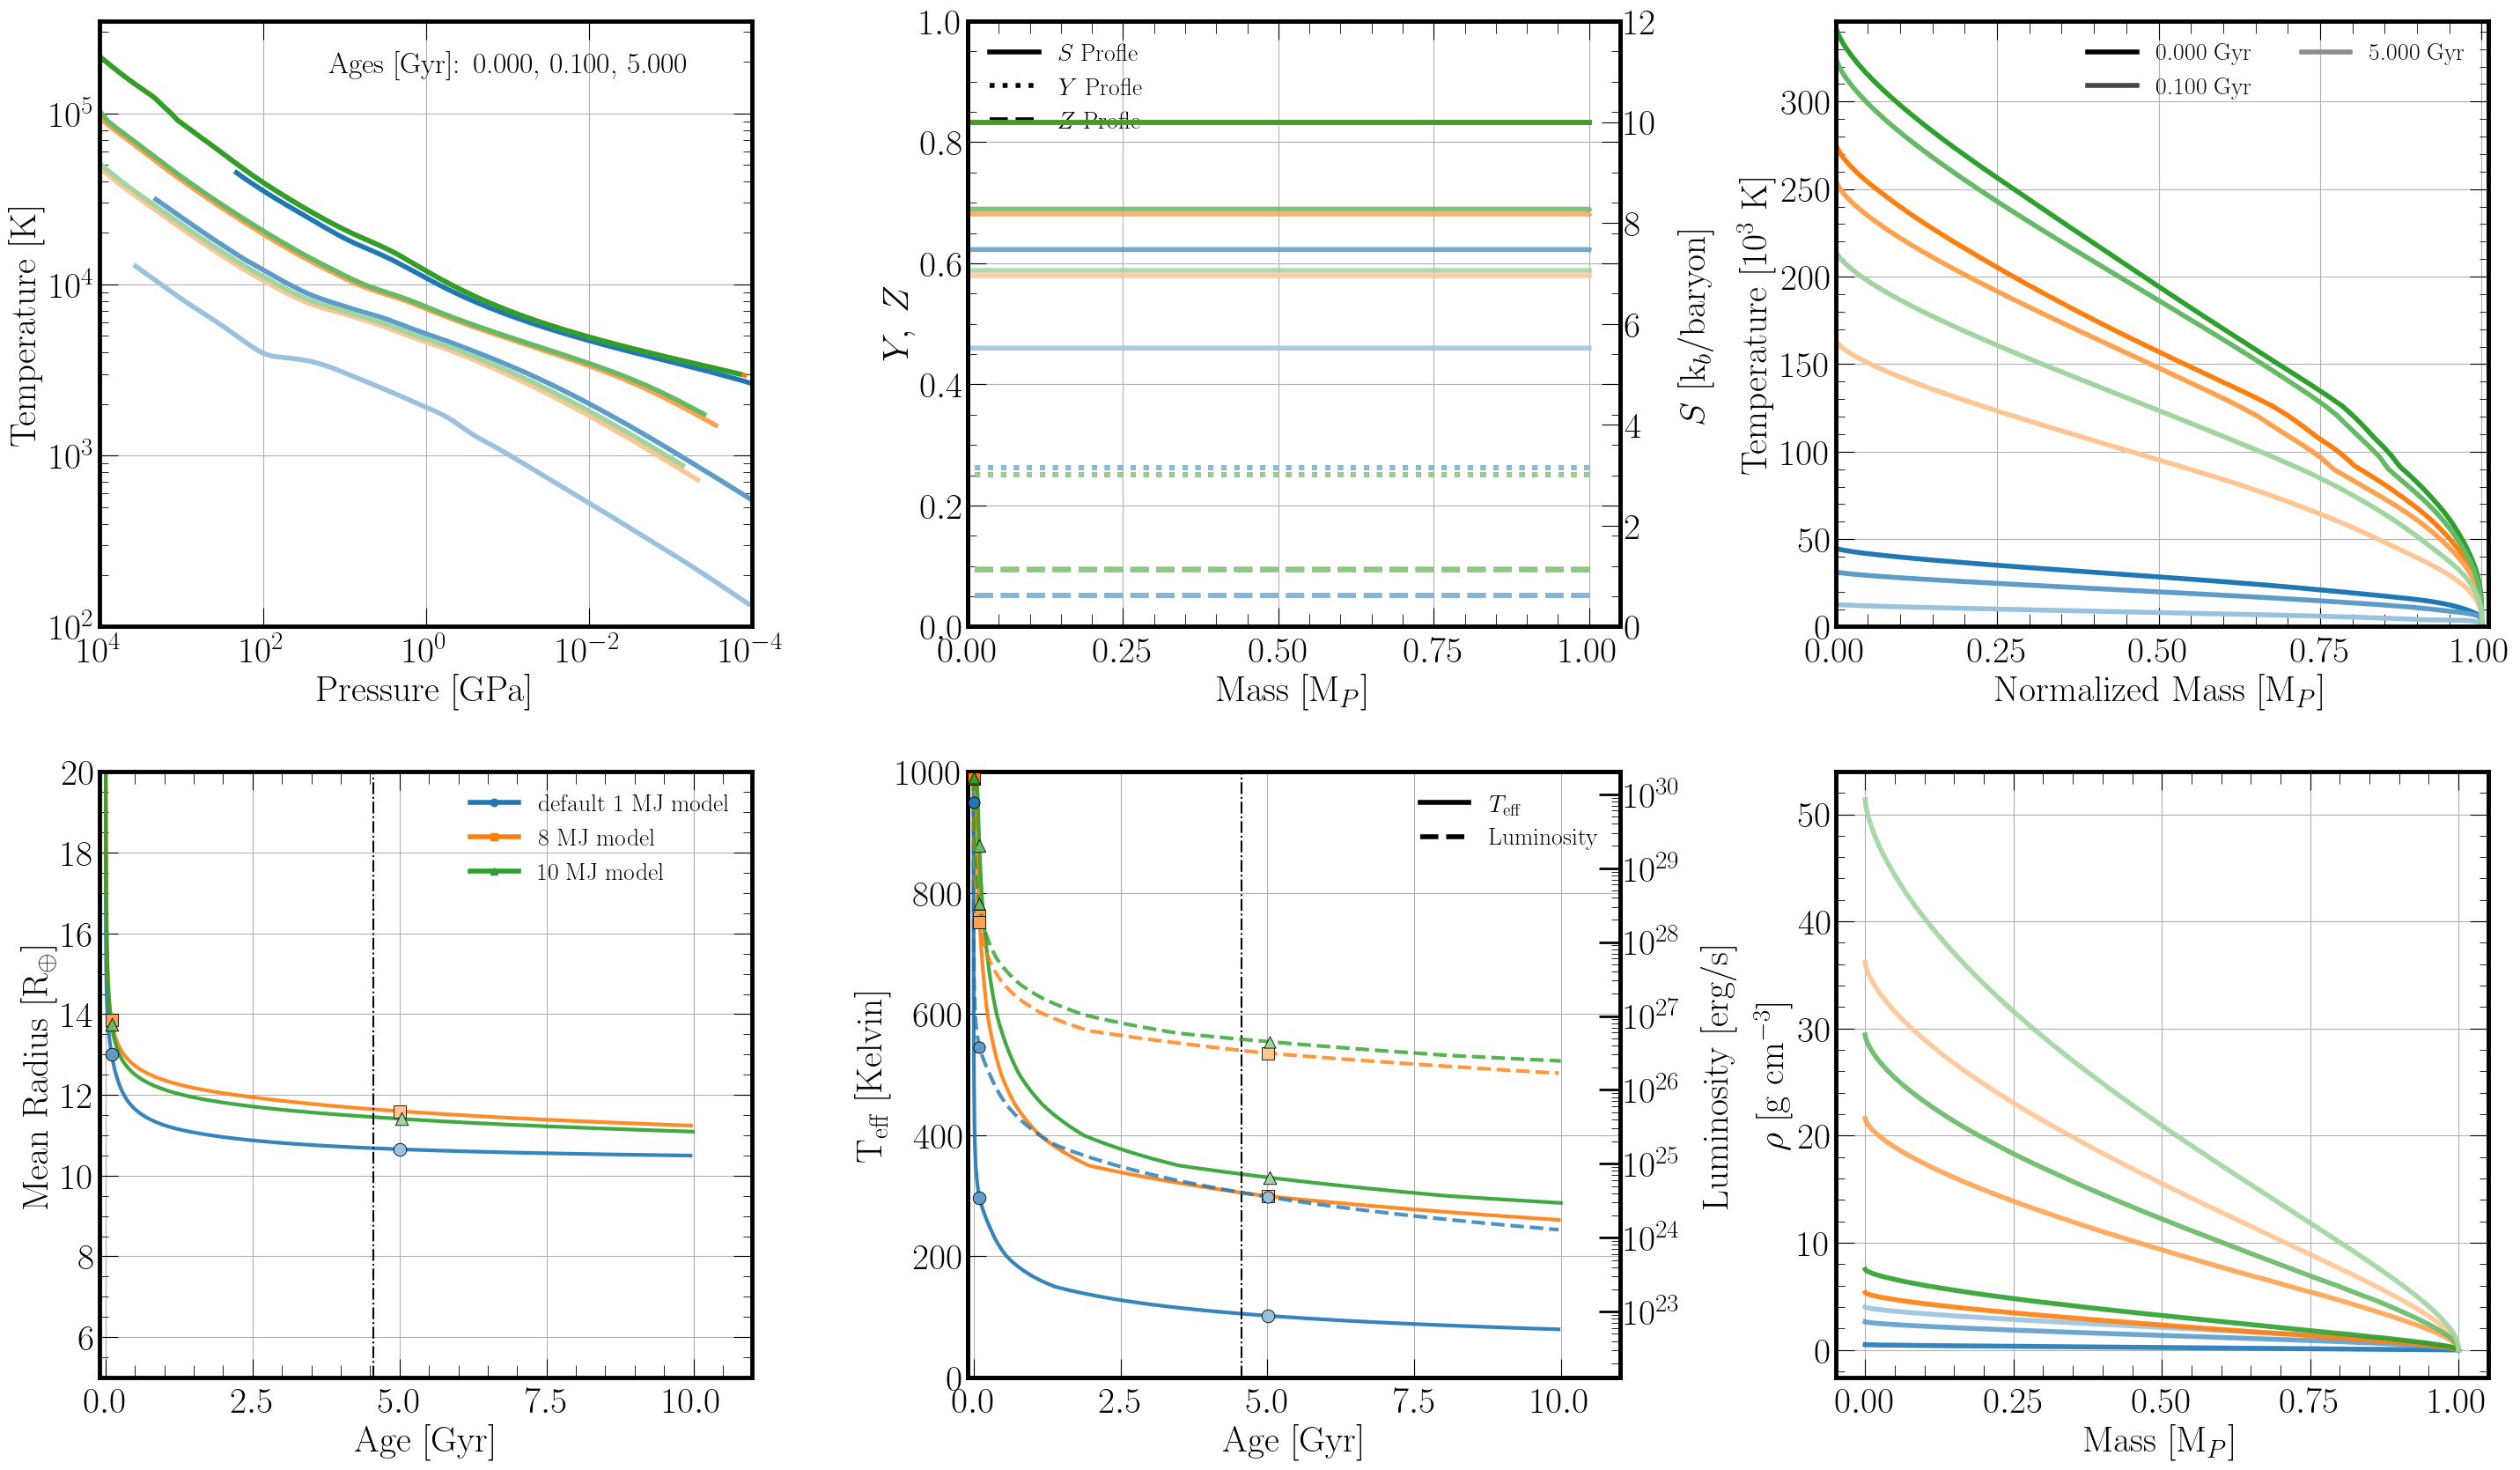

In [1]:
import plot_class

paths = [
    "parameter_examples/parameter_user.ini",
    "parameter_examples/parameter_user_8mj.ini",
    "parameter_examples/parameter_user_10mj.ini"
]


init = plot_class.init_plot(paths = paths)

labels = [
    r'default 1 MJ model',
    r'8 MJ model',
    r'10 MJ model'
]


init.age_plot(
    ages=[0.0, 0.1, 5.0],
    output_file='age_compare',
    labels=labels,
    save=False, # option to save the plot in the plots/ folder
    leg_size=20,
)


**WARNING**: If you set a compact core to these super-Jupiter models, the core EOS may not encompass the pressures and temperatures demanded of it, so the code might fail. I recommend not incorporating compact cores in super-Jupiter models since compact cores are likely less influential in these mass regimes.

**NOTE**: All of these example models use `Z_ini = 0.017`, which is roughly 1× solar with $Z_\odot = 0.017$ (Chen et al. 2023). The total metal mass therefore scales with the planet's total mass. This is for demonstration purposes only.

**NOTE**: All the models in this tutorial are isolated (no irradiation), because the `c26` boundary condition tables are built for isolated super-Jupiters. If you want a strongly irradiated giant, use the `c23` tables with `irradiation = True` and an appropriate `t_eq` (see the Jupiter examples in `tutorial_solarsystem_planets.ipynb`). Keep in mind that reproducing the most inflated hot Jupiters requires additional heating mechanisms that we do not model here. That exploration is left as an exercise to the reader.

## Homogeneous/adiabatic M-R relation for Jupiter-sized planets

Let's compute an additional 0.1, 0.3 (Saturn-ish mass), 2, 3 and 5 Jupiter mass evolution models and build an M-R relation. All of these models share the same composition and are isolated, so this is a fixed-composition cooling M-R relation, not a population prediction. Above roughly 13 M$_J$ deuterium burning becomes relevant, and `ORCHARD` does not model it, so treat everything here as planetary structures only.

In [2]:
import load_models
from utils import const

paths = [
    "parameter_examples/parameter_user_0.1mj.ini",
    "parameter_examples/parameter_user_0.3mj.ini",
    "parameter_examples/parameter_user.ini",
    "parameter_examples/parameter_user_2mj.ini",
    "parameter_examples/parameter_user_3mj.ini",
    "parameter_examples/parameter_user_5mj.ini",
    "parameter_examples/parameter_user_8mj.ini",
    "parameter_examples/parameter_user_10mj.ini",

]

models = load_models.load(paths)

Reading files...


Finished reading files...


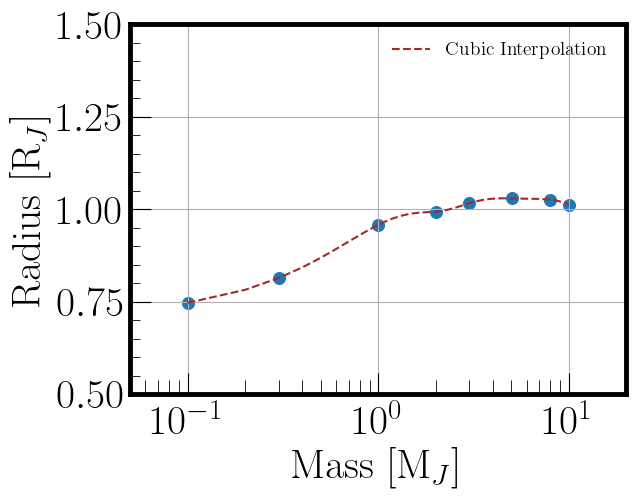

In [3]:
radius_final = [models[i]['data_rad'][-1]/const.rjup for i in range(len(paths))]
masses = [models[i]['mass_grid'][0]/const.mjup for i in range(len(paths))]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

r_M = interp1d(masses, radius_final, kind='cubic', fill_value='extrapolate') # simple cubic interpolation for demonstration purposes only

masses_interp = np.linspace(0.1, 10.0, 100)
radius_interp = r_M(masses_interp)


plt.scatter(masses, radius_final, s=70)
plt.plot(masses_interp, radius_interp, label='Cubic Interpolation', color='brown', ls='--')
plt.xscale('log')
plt.xlabel(r'Mass [M$_J$]')
plt.ylabel(r'Radius [R$_J$]')
plt.minorticks_on()
plt.ylim(0.5, 1.5)
plt.xlim(0.05, 20)
plt.legend(frameon=False, fontsize=14)
plt.show()

This is only an exercise. In reality, the observed M-R relation yields smaller radii above about a Saturn mass; see Chen & Kipping (2017, *ApJ* 834, 17) and Müller et al. (2024) for empirical fits. The smooth cubic interpolation above (drawn through 8 model points) is a visualization only; treat it as a sketch of the trend rather than a quantitative prediction. Real Jupiter-class exoplanets also span a wide range of insolation, age, and helium/metal fractionation, all of which affect the observed radius.

## Atmospheric spectra as a post-process

The evolution gives us $T_{\rm eff}$, $\log g$, and the atmospheric $Y$ and $Z$ at every age. The `c26` atmosphere models (Chen et al. 2026) that set the boundary condition also come with emergent spectra tabulated on the same grid, so we can turn any evolutionary track into a sequence of spectra without rerunning anything. This is strictly a post-process: it reads the saved model and interpolates the spectral tables, and it never feeds back into the evolution.

The interface is `atm_spectra/spectrum.py`. Instantiating `spectrum.spectrum()` loads the table (`spectrum_data_YZ_C26.npz`), and `interpolate_spectrum_4D()` returns the wavelength grid and the frequency flux $F_\nu$ at a given $(T_{\rm eff}, \log g, Y, Z)$.

**NOTE**: `interpolate_spectrum_4D` expects $Z$ in **solar units**, not the mass fraction that `ORCHARD` carries internally. The helper below does the conversion with $Z_\odot = 0.017$ (Chen et al. 2023). Passing a mass fraction directly is the easiest mistake to make here, and it will silently land you at the bottom edge of the metallicity grid.

Reading files...
Finished reading files...


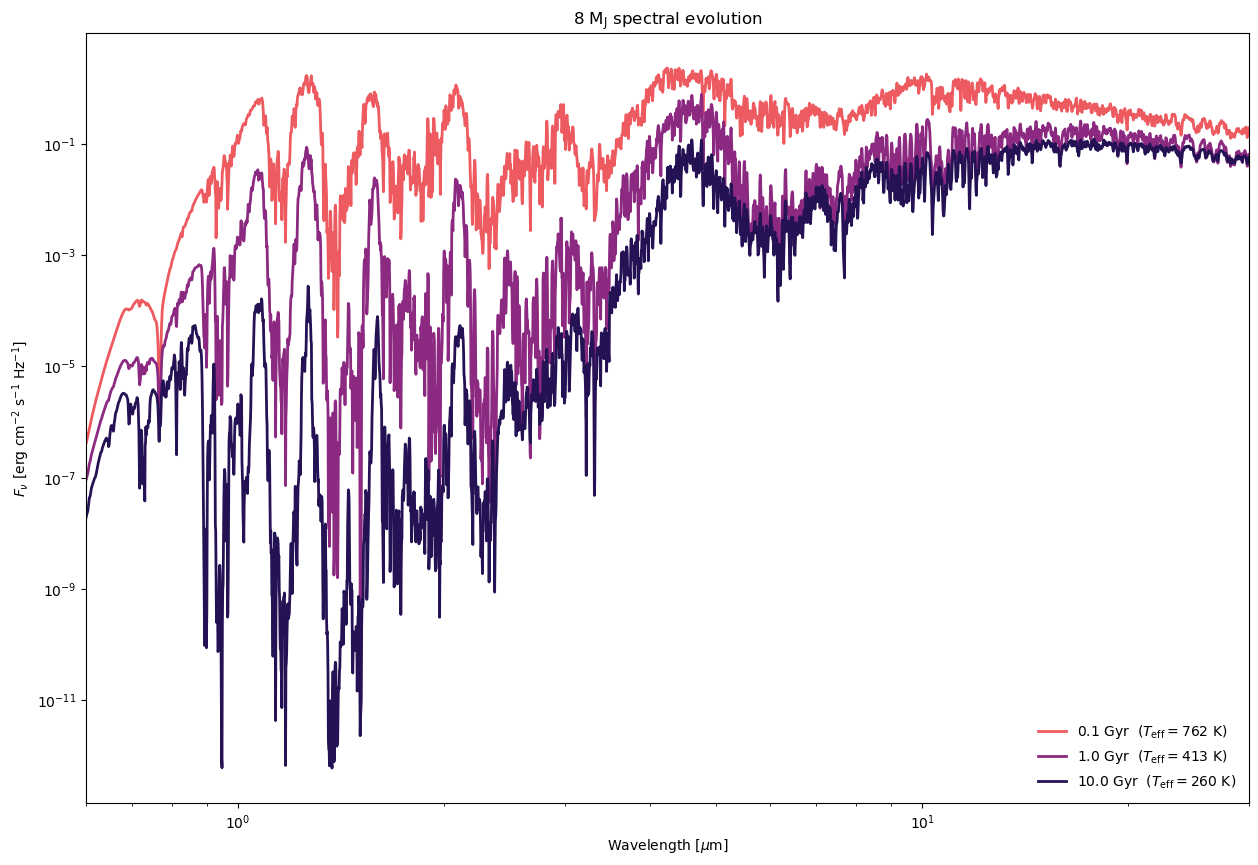

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import load_models
from utils import const
from atm_spectra import spectrum

spec = spectrum.spectrum()

# The 8 M_J model from above. Any evolved model works.
model = load_models.load(["parameter_examples/parameter_user_8mj.ini"])[0]
age_gyr = model['data_age'] * const.s_to_Gyr


def z_to_solar(z_mass, z_solar=0.017):
    # metal mass fraction -> metallicity in solar units
    return (z_mass / (1.0 - z_mass)) / (z_solar / (1.0 - z_solar))


ages = [0.1, 1.0, 10.0]
colors = plt.cm.magma_r(np.linspace(0.35, 0.85, len(ages)))

fig, ax = plt.subplots(figsize=(15, 10))
for age, color in zip(ages, colors):
    i = np.argmin(np.abs(age_gyr - age))
    lam, flux = spec.interpolate_spectrum_4D(
        Teff_in=model['data_teff'][i],
        logg_in=np.log10(model['data_grav'][i]),
        Y_in=model['data_Y_atm'][i],
        Z_in=z_to_solar(model['data_Z_atm'][i]),
    )
    ax.plot(lam, flux, color=color, lw=2,
            label=f"{age_gyr[i]:.1f} Gyr  ($T_{{\\rm eff}} = {model['data_teff'][i]:.0f}$ K)")

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(0.6, 30)
ax.set_xlabel(r'Wavelength [$\mu$m]')
ax.set_ylabel(r'$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')
ax.set_title(r'8 M$_{\rm J}$ spectral evolution')
ax.legend(frameon=False)
plt.show()

The planet cools from $T_{\rm eff} \approx 760$ K at 0.1 Gyr to $\approx 260$ K at 10 Gyr, and the spectrum drops and shifts redward as it goes. The flux falls by more than an order of magnitude in the near-infrared while the mid-infrared holds up better, which is the usual reason direct-imaging surveys favor young planets and longer wavelengths.

**NOTE**: The tables span $T_{\rm eff} \in [100, 1400]$ K, $\log g \in [2.8, 4.4]$, $Y \in \{0.15, 0.275\}$, and $Z \in \{1, 3.16, 10\}\ Z_\odot$. Inputs outside those ranges are clipped to the nearest edge rather than extrapolated, so a very young (hot) or very low-gravity model will quietly return the edge spectrum. Check $T_{\rm eff}$ and $\log g$ against the grid before reading too much into a curve.

There is also a convenience method, `spectrum_evolution()`, which takes whole trajectories instead of one snapshot at a time and returns the stacked spectra. It is handy when you want the flux at a fixed wavelength as a function of age.

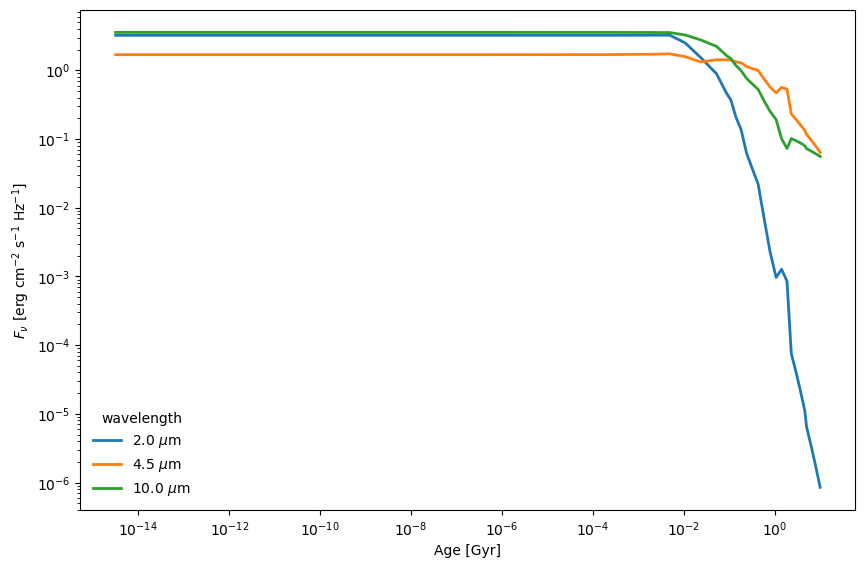

In [2]:
# Flux at a few JWST-ish wavelengths as a function of age, via spectrum_evolution
idx = np.linspace(1, len(age_gyr) - 1, 40, dtype=int)   # 40 snapshots along the track

lam, all_flux = spec.spectrum_evolution(
    N_frames=len(idx),
    age_path=age_gyr[idx],
    Teff_path=model['data_teff'][idx],
    logg_path=np.log10(model['data_grav'][idx]),
    Z_path=z_to_solar(model['data_Z_atm'][idx]),
    Y_path=model['data_Y_atm'][idx],
    plot=False,
)

fig, ax = plt.subplots(figsize=(10, 6.5))
for lam_target in (2.0, 4.5, 10.0):
    j = np.argmin(np.abs(lam - lam_target))
    ax.plot(age_gyr[idx], all_flux[:, j], lw=2,
            label=rf'{lam[j]:.1f} $\mu$m')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel(r'$F_\nu$ [erg cm$^{-2}$ s$^{-1}$ Hz$^{-1}$]')
ax.legend(frameon=False, title='wavelength')
plt.show()

Both fade as the planet cools, but the 2 $\mu$m flux falls far more steeply than the 10 $\mu$m flux: the near-infrared sits on the Wien side of the spectral energy distribution and is exponentially sensitive to $T_{\rm eff}$, while the mid-infrared is closer to the Rayleigh-Jeans regime.

These are model fluxes at the planet's surface. To compare against an observation you still need to scale by $(R_p/d)^2$ for the distance $d$, and the spectra assume the isolated (`c26`) atmosphere, so they are not appropriate for a strongly irradiated planet.

**Exercise**: Repeat the first figure for the 1 M$_J$ and 10 M$_J$ models at a fixed age. At the same age, the more massive planet is hotter and has a higher $\log g$; see which of the two effects wins in the near-infrared.